# Feature Engineering & Preprocessing

**Objective:**
Based on the findings from our EDA (Notebook 01), we identified two critical issues: unscaled features (`Time` and `Amount`) containing outliers, and extreme class imbalance. 

**Goals for this notebook:**
1. Test feature scaling strategies using `RobustScaler` (which is immune to outliers).
2. Establish a rigorous `Train/Test` split to prevent data leakage.
3. Implement and validate SMOTE (Synthetic Minority Over-sampling Technique) strictly on the training set to resolve the class imbalance.


In [29]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for preprocessing and splitting
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# Imblearn for handling class imbalance
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
We reload the raw dataset and immediately drop the duplicated rows we identified during the EDA phase.


In [30]:
df = pd.read_csv('../data/raw/creditcard.csv')

# Drop duplicates as determined in EDA
df = df.drop_duplicates()

In [22]:
print(f"Initial Dataset before dropping duplicates: {df.shape}")

Initial Dataset before dropping duplicates: (283726, 31)


In [23]:
print(f"Data shape after dropping duplicates: {df.shape}")

Data shape after dropping duplicates: (283726, 31)


## 2. Feature Scaling (`Time` and `Amount`)
**Why `RobustScaler`?** 
In Notebook 01, we saw that the `Amount` feature is highly skewed with extreme outliers (which is typical for fraudulent transactions). A `StandardScaler` uses the mean, which is heavily distorted by outliers. `RobustScaler` uses the median and the Interquartile Range (IQR), making it perfectly suited for financial anomaly data.


In [24]:
# Initialize the scaler
robust_scaler = RobustScaler()

# Create new scaled columns
df['scaled_amount'] = robust_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = robust_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop the old, unscaled columns
df.drop(['Time','Amount'], axis=1, inplace=True)

# Move the new scaled columns to the front of the dataframe for clean structure
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print(df.head())


   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       1.774718    -0.995290 -1.359807 -0.072781  2.536347  1.378155   
1      -0.268530    -0.995290  1.191857  0.266151  0.166480  0.448154   
2       4.959811    -0.995279 -1.358354 -1.340163  1.773209  0.379780   
3       1.411487    -0.995279 -0.966272 -0.185226  1.792993 -0.863291   
4       0.667362    -0.995267 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       V27       V28  Class  
0 -0.1104

## 3. Data Leakage Prevention: Train/Test Split
> **CRITICAL STEP:** We must split our data into Training and Testing sets *before* applying SMOTE. If we oversample first and then split, synthetic data points will leak into the testing set, causing our model to memorize the data and report artificially high evaluation scores.

We use `stratify=y` to ensure the testing set contains the exact same ratio of fraud as the real world.


In [25]:
# Separate Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Perform a stratfied 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original Training Set shape: {X_train.shape}")
print(f"Original Testing Set shape: {X_test.shape}")
print(f"Fraud ratio in Training: {y_train.sum() / len(y_train) * 100:.3f}%")

Original Training Set shape: (226980, 30)
Original Testing Set shape: (56746, 30)
Fraud ratio in Training: 0.167%


## 4. Handling Imbalance with SMOTE
Now that our test set is safely locked away, we will apply **SMOTE** to the training data. SMOTE creates synthetic fraudulent transactions by interpolating between existing fraud points, forcing our training set to be perfectly balanced (50/50).


Before SMOTE - Normal (0): 226602, Fraud (1): 378
After SMOTE  - Normal (0): 226602, Fraud (1): 226602


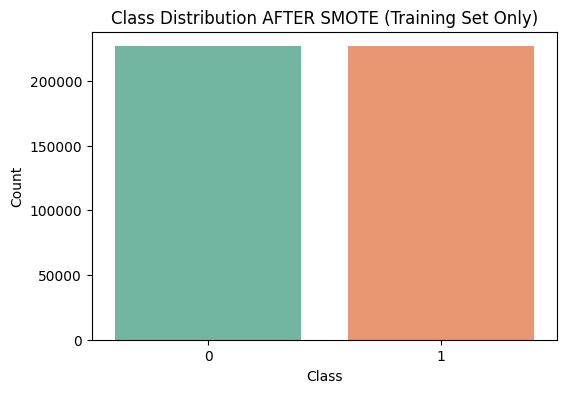

In [27]:
from IPython.core import pylabtools
from IPython.core import pylabtools
print(f"Before SMOTE - Normal (0): {sum(y_train == 0)}, Fraud (1): {sum(y_train == 1)}")

# Initialize and apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  - Normal (0): {sum(y_train_smote == 0)}, Fraud (1): {sum(y_train_smote == 1)}")

# Visualize the new balanced training set
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote, palette='Set2')
plt.title('Class Distribution AFTER SMOTE (Training Set Only)')
plt.ylabel('Count')
plt.show()

## 🎯 Key Findings & Next Steps

1. **Robust Scaling Validated**: `RobustScaler` successfully normalized `Time` and `Amount` without being distorted by extreme transaction values.
2. **Leakage Prevented**: By splitting the data *before* applying SMOTE, we guarantee that our `X_test` set represents raw, untouched, real-world data.
3. **Balanced Training Engine**: SMOTE successfully upsampled the fraudulent class, providing us with a perfectly balanced `X_train_smote` dataset (over 220,000 samples of each class). This ensures our future algorithms will not ignore the minority class.
